<a href="https://colab.research.google.com/github/manavdhelia/ML-for-engineers/blob/HW5/HW5_problem2_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECE 601 - Homework 5, Problem 2
## k-NN Classification on the Penguins Dataset with Cross-Validation

In [2]:
!pip install palmerpenguins scikit-learn seaborn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from palmerpenguins import load_penguins
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

SEED = 42

## 1. Load and Preprocess the Dataset

In [3]:
df = load_penguins()
df.dropna(inplace=True)
print(f"Dataset shape after cleaning: {df.shape}")

le_island  = LabelEncoder()
le_sex     = LabelEncoder()
le_species = LabelEncoder()

df['island_enc']  = le_island.fit_transform(df['island'])
df['sex_enc']     = le_sex.fit_transform(df['sex'])
df['species_enc'] = le_species.fit_transform(df['species'])

FEATURES = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_enc']
X = df[FEATURES].values

print("Species distribution:\n", df['species'].value_counts())
print("\nSex distribution:\n", df['sex'].value_counts())

Dataset shape after cleaning: (333, 8)
Species distribution:
 species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Sex distribution:
 sex
male      168
female    165
Name: count, dtype: int64


## 2. Species Classifier — k-NN with Cross-Validation

In [4]:
# Train/test split
y_species = df['species_enc'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y_species, test_size=0.2, random_state=SEED, stratify=y_species
)

# Standardize features (required for kNN — distance-based)
scaler_sp = StandardScaler()
X_train_sc = scaler_sp.fit_transform(X_train)
X_test_sc  = scaler_sp.transform(X_test)

# 5-fold cross-validation over k = 1..30
k_range = range(1, 31)
cv_scores_species = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='accuracy')
    cv_scores_species.append(scores.mean())

best_k_species = list(k_range)[np.argmax(cv_scores_species)]
print(f"Best k for Species: {best_k_species}")
print(f"Best CV Accuracy  : {max(cv_scores_species):.4f}")

Best k for Species: 3
Best CV Accuracy  : 0.9962


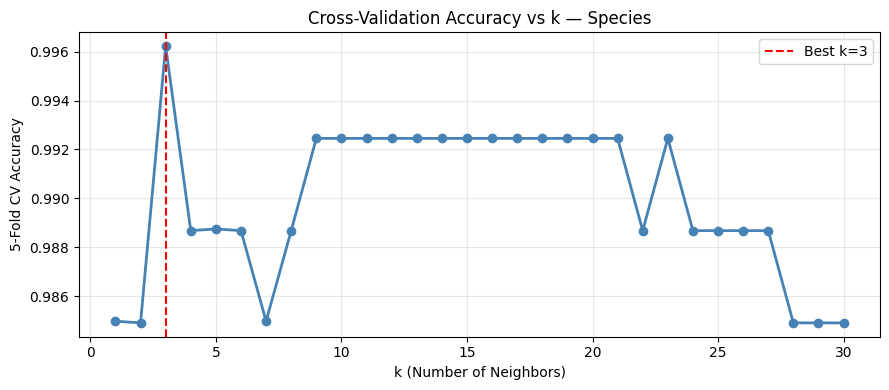

In [5]:
# Plot CV accuracy vs k — Species
plt.figure(figsize=(9, 4))
plt.plot(k_range, cv_scores_species, marker='o', linewidth=2, color='steelblue')
plt.axvline(best_k_species, color='red', linestyle='--', label=f'Best k={best_k_species}')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('5-Fold CV Accuracy')
plt.title('Cross-Validation Accuracy vs k — Species')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Train and evaluate final species kNN
t0 = time.time()
knn_species = KNeighborsClassifier(n_neighbors=best_k_species)
knn_species.fit(X_train_sc, y_train)
train_time_sp = time.time() - t0

t0 = time.time()
y_pred_species = knn_species.predict(X_test_sc)
pred_time_sp = time.time() - t0

print("=" * 50)
print(f"SPECIES kNN  (k = {best_k_species})")
print("=" * 50)
print(f"Test Accuracy  : {accuracy_score(y_test, y_pred_species):.4f}")
print(f"Train time     : {train_time_sp*1000:.2f} ms")
print(f"Predict time   : {pred_time_sp*1000:.2f} ms")
print()
print(classification_report(y_test, y_pred_species, target_names=le_species.classes_))

SPECIES kNN  (k = 3)
Test Accuracy  : 1.0000
Train time     : 2.29 ms
Predict time   : 2.52 ms

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



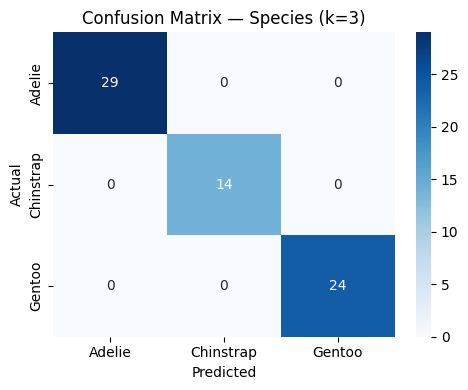

In [7]:
# Confusion matrix — Species
cm = confusion_matrix(y_test, y_pred_species)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_species.classes_, yticklabels=le_species.classes_)
plt.title(f'Confusion Matrix — Species (k={best_k_species})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 3. Sex Classifier — k-NN with Cross-Validation

In [8]:
# Train/test split
y_sex = df['sex_enc'].values
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_sex, test_size=0.2, random_state=SEED, stratify=y_sex
)

scaler_sx = StandardScaler()
X_train2_sc = scaler_sx.fit_transform(X_train2)
X_test2_sc  = scaler_sx.transform(X_test2)

# 5-fold CV over k = 1..30
cv_scores_sex = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train2_sc, y_train2, cv=5, scoring='accuracy')
    cv_scores_sex.append(scores.mean())

best_k_sex = list(k_range)[np.argmax(cv_scores_sex)]
print(f"Best k for Sex : {best_k_sex}")
print(f"Best CV Accuracy: {max(cv_scores_sex):.4f}")

Best k for Sex : 3
Best CV Accuracy: 0.9098


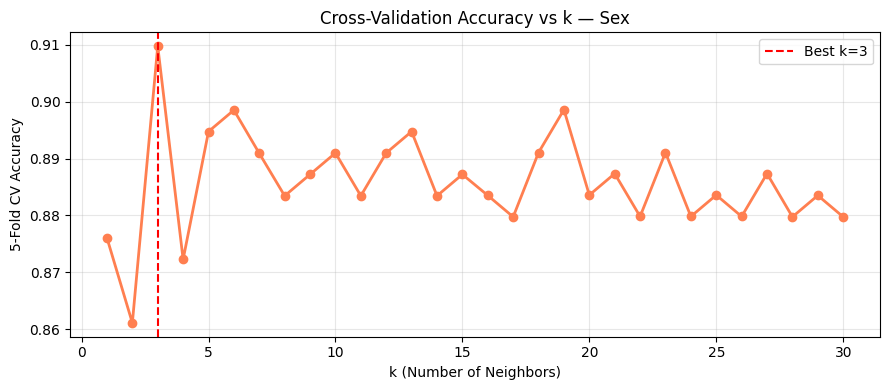

In [9]:
# Plot CV accuracy vs k — Sex
plt.figure(figsize=(9, 4))
plt.plot(k_range, cv_scores_sex, marker='o', linewidth=2, color='coral')
plt.axvline(best_k_sex, color='red', linestyle='--', label=f'Best k={best_k_sex}')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('5-Fold CV Accuracy')
plt.title('Cross-Validation Accuracy vs k — Sex')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Train and evaluate final sex kNN
t0 = time.time()
knn_sex = KNeighborsClassifier(n_neighbors=best_k_sex)
knn_sex.fit(X_train2_sc, y_train2)
train_time_sx = time.time() - t0

t0 = time.time()
y_pred_sex = knn_sex.predict(X_test2_sc)
pred_time_sx = time.time() - t0

print("=" * 50)
print(f"SEX kNN  (k = {best_k_sex})")
print("=" * 50)
print(f"Test Accuracy  : {accuracy_score(y_test2, y_pred_sex):.4f}")
print(f"Train time     : {train_time_sx*1000:.2f} ms")
print(f"Predict time   : {pred_time_sx*1000:.2f} ms")
print()
print(classification_report(y_test2, y_pred_sex, target_names=le_sex.classes_))

SEX kNN  (k = 3)
Test Accuracy  : 0.8806
Train time     : 2.69 ms
Predict time   : 2.70 ms

              precision    recall  f1-score   support

      female       0.88      0.88      0.88        33
        male       0.88      0.88      0.88        34

    accuracy                           0.88        67
   macro avg       0.88      0.88      0.88        67
weighted avg       0.88      0.88      0.88        67



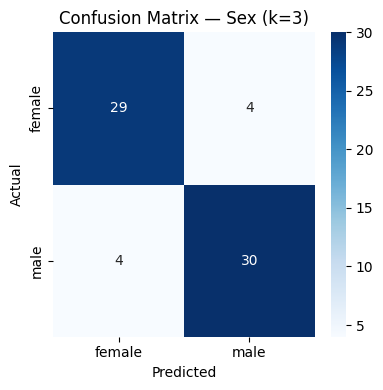

In [11]:
# Confusion matrix — Sex
cm2 = confusion_matrix(y_test2, y_pred_sex)
plt.figure(figsize=(4, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_sex.classes_, yticklabels=le_sex.classes_)
plt.title(f'Confusion Matrix — Sex (k={best_k_sex})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 4. Timing Comparison: kNN vs Decision Tree vs Logistic Regression

In [12]:
results = {}

# --- Decision Tree ---
for label, Xtr, Xte, ytr, yte in [
    ('Species', X_train, X_test, y_train, y_test),
    ('Sex',     X_train2, X_test2, y_train2, y_test2)
]:
    t0 = time.time(); dt = DecisionTreeClassifier(random_state=SEED); dt.fit(Xtr, ytr); dt_tr = time.time()-t0
    t0 = time.time(); yp = dt.predict(Xte); dt_pr = time.time()-t0
    results[f'DT-{label}'] = {'acc': accuracy_score(yte, yp), 'train_ms': dt_tr*1000, 'pred_ms': dt_pr*1000}

# --- Logistic Regression ---
for label, Xtr, Xte, ytr, yte in [
    ('Species', X_train_sc, X_test_sc, y_train, y_test),
    ('Sex',     X_train2_sc, X_test2_sc, y_train2, y_test2)
]:
    t0 = time.time(); lr = LogisticRegression(max_iter=1000, random_state=SEED); lr.fit(Xtr, ytr); lr_tr = time.time()-t0
    t0 = time.time(); yp = lr.predict(Xte); lr_pr = time.time()-t0
    results[f'LR-{label}'] = {'acc': accuracy_score(yte, yp), 'train_ms': lr_tr*1000, 'pred_ms': lr_pr*1000}

# kNN results already stored
results['kNN-Species'] = {'acc': accuracy_score(y_test,  y_pred_species), 'train_ms': train_time_sp*1000, 'pred_ms': pred_time_sp*1000}
results['kNN-Sex']     = {'acc': accuracy_score(y_test2, y_pred_sex),     'train_ms': train_time_sx*1000, 'pred_ms': pred_time_sx*1000}

print(f"{'Model':<18} {'Accuracy':>10} {'Train(ms)':>12} {'Predict(ms)':>13}")
print("-" * 55)
for model in ['kNN-Species','DT-Species','LR-Species','kNN-Sex','DT-Sex','LR-Sex']:
    r = results[model]
    print(f"{model:<18} {r['acc']:>10.4f} {r['train_ms']:>12.2f} {r['pred_ms']:>13.2f}")

Model                Accuracy    Train(ms)   Predict(ms)
-------------------------------------------------------
kNN-Species            1.0000         2.29          2.52
DT-Species             0.9552         2.60          0.36
LR-Species             1.0000        14.22          0.29
kNN-Sex                0.8806         2.69          2.70
DT-Sex                 0.8955         2.81          0.25
LR-Sex                 0.8955         5.21          0.24


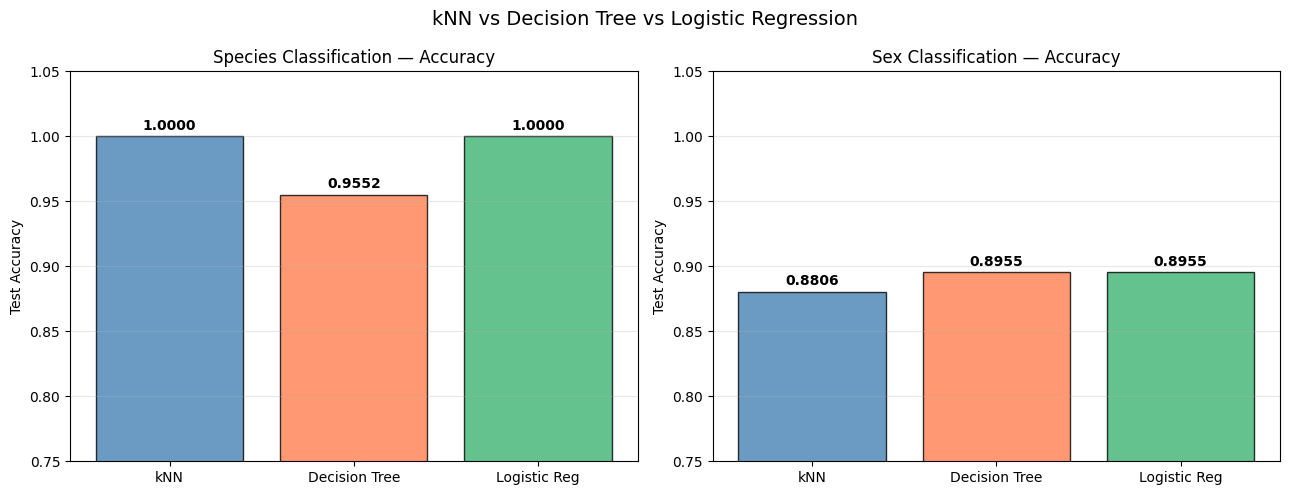

In [13]:
# Accuracy comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, task in zip(axes, ['Species', 'Sex']):
    models = ['kNN', 'Decision Tree', 'Logistic Reg']
    accs = [results[f'kNN-{task}']['acc'],
            results[f'DT-{task}']['acc'],
            results[f'LR-{task}']['acc']]
    colors = ['steelblue', 'coral', 'mediumseagreen']
    bars = ax.bar(models, accs, color=colors, alpha=0.8, edgecolor='black')
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{acc:.4f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_ylim([0.75, 1.05])
    ax.set_title(f'{task} Classification — Accuracy', fontsize=12)
    ax.set_ylabel('Test Accuracy')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('kNN vs Decision Tree vs Logistic Regression', fontsize=14)
plt.tight_layout()
plt.show()

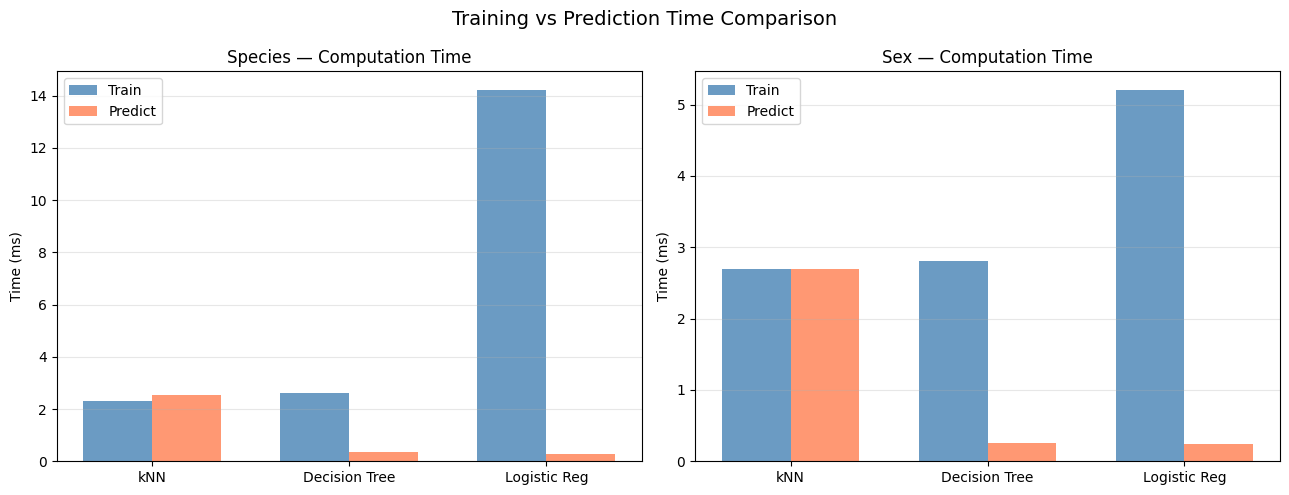

In [14]:
# Training time comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, task in zip(axes, ['Species', 'Sex']):
    models = ['kNN', 'Decision Tree', 'Logistic Reg']
    train_times = [results[f'kNN-{task}']['train_ms'],
                   results[f'DT-{task}']['train_ms'],
                   results[f'LR-{task}']['train_ms']]
    pred_times  = [results[f'kNN-{task}']['pred_ms'],
                   results[f'DT-{task}']['pred_ms'],
                   results[f'LR-{task}']['pred_ms']]

    x = np.arange(len(models))
    w = 0.35
    ax.bar(x - w/2, train_times, w, label='Train', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, pred_times,  w, label='Predict', color='coral', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylabel('Time (ms)')
    ax.set_title(f'{task} — Computation Time', fontsize=12)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Training vs Prediction Time Comparison', fontsize=14)
plt.tight_layout()
plt.show()